# Imports

In [1]:
from src.preprocess import preprocess_folder
from pathlib import Path

# Config

In [10]:
data_root = Path("../data")
cache_root = Path("../cache/200hz")
downsample_factor = 10
eps = 1e-20
force = False

In [11]:
input_folders = sorted(
    folder
    for folder in data_root.rglob("*")
    if folder.is_dir() and any(folder.glob("*.h5"))
)

for input_folder in input_folders:
    output_folder = cache_root / input_folder.relative_to(data_root)

    preprocess_folder(
        input_folder=input_folder,
        output_folder=output_folder,
        downsample_factor=downsample_factor,
        eps=eps,
        force=force,
    )

Input folder: /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/data/Cross/test1
Output folder: /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/cache/200hz/Cross/test1
Found 16 h5 files
Downsample factor: 10
Effective sampling rate: 203.40 Hz
Epsilon: 1e-20

Saved /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/cache/200hz/Cross/test1/rest_162935_1.npy | shape=(248, 3563)
Saved /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/cache/200hz/Cross/test1/rest_162935_10.npy | shape=(248, 3563)
Saved /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/cache/200hz/Cross/test1/rest_162935_3.npy | shape=(248, 3563)
Saved /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/cache/200hz/Cross/test1/rest_162935_5.npy | shape=(248, 3563)
Saved /Users/fabiodijkshoorn/Documents/UU/Deep Learning/assignment-2-final/cache/200hz/Cross/test1/task_motor_162935_1.npy | shape=(248, 3563)
Saved /Us

# Data loading

In [13]:
from src.loader import MEGDataset
from torch.utils.data import DataLoader
from src.utilities import list_npy_files

all_files = list_npy_files("../cache/base/Cross/train")

dataset = MEGDataset(all_files, window_seconds=7.0)

dataset_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

# Data Exploration

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from src.loader import LABEL_MAP
from scipy.signal import welch
from sklearn.decomposition import PCA


INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

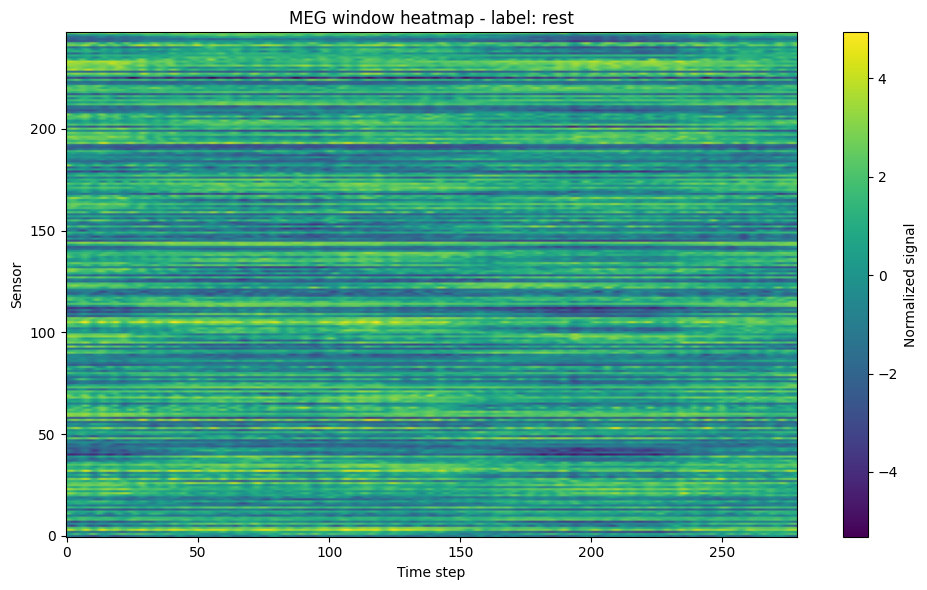

In [6]:
def plot_window_heatmap(dataset, idx=0):
    x, y = dataset[idx]
    x = x.numpy()

    plt.figure(figsize=(10, 6))
    plt.imshow(x, aspect="auto", origin="lower")
    plt.colorbar(label="Normalized signal")
    plt.xlabel("Time step")
    plt.ylabel("Sensor")
    plt.title(f"MEG window heatmap - label: {INV_LABEL_MAP[int(y)]}")
    plt.tight_layout()
    plt.show()

plot_window_heatmap(dataset, idx=0)

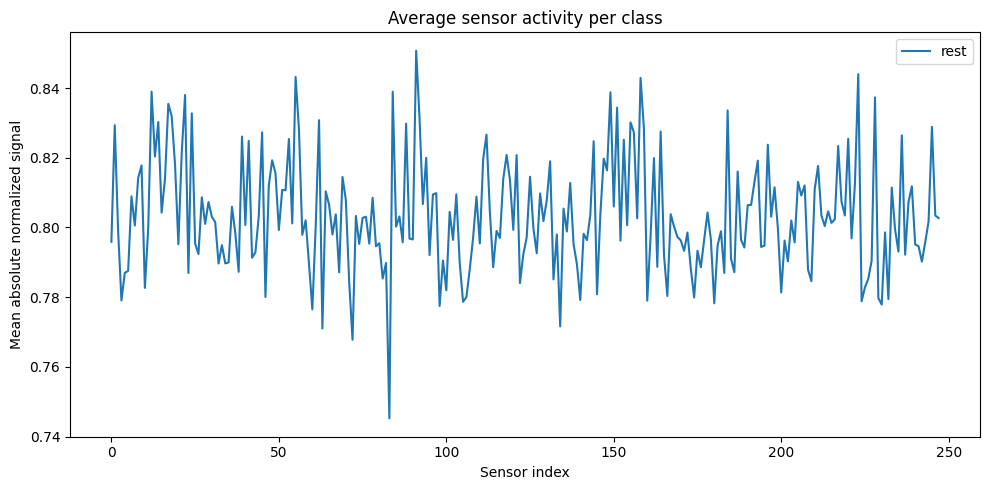

In [7]:
def compute_class_average_abs_signal(dataset, max_items=None):
    sums = {}
    counts = {}

    n = len(dataset) if max_items is None else min(len(dataset), max_items)

    for i in range(n):
        x, y = dataset[i]
        label = int(y)

        value = x.abs().mean(dim=1).numpy()  # average absolute activity per sensor

        if label not in sums:
            sums[label] = value
            counts[label] = 0

        sums[label] += value
        counts[label] += 1

    averages = {label: sums[label] / counts[label] for label in sums}
    return averages

def plot_class_sensor_activity(dataset, max_items=500):
    averages = compute_class_average_abs_signal(dataset, max_items=max_items)

    plt.figure(figsize=(10, 5))
    for label, avg in sorted(averages.items()):
        plt.plot(avg, label=INV_LABEL_MAP[label])

    plt.xlabel("Sensor index")
    plt.ylabel("Mean absolute normalized signal")
    plt.title("Average sensor activity per class")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_class_sensor_activity(dataset, max_items=500)

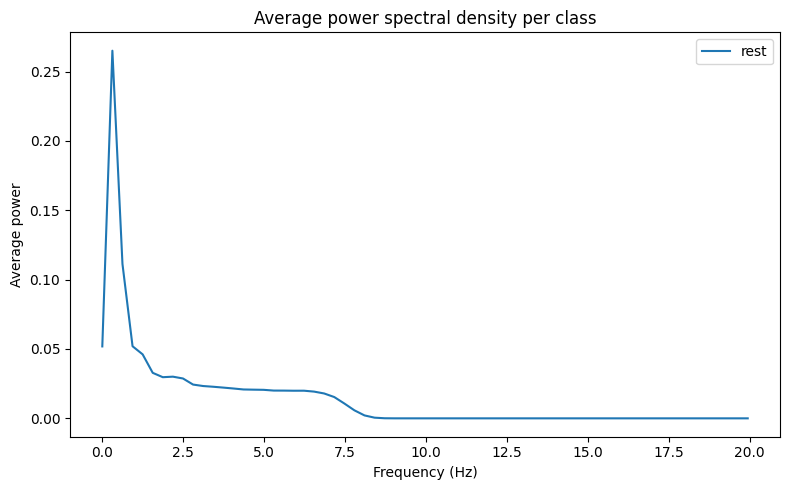

In [8]:
def plot_average_psd_by_class(dataset, max_items=300):
    sampling_rate = dataset.sampling_rate

    psd_sums = {}
    counts = {}
    freqs_ref = None

    n = min(len(dataset), max_items)

    for i in range(n):
        x, y = dataset[i]
        x = x.numpy()
        label = int(y)

        # Average PSD over sensors
        freqs, psd = welch(x, fs=sampling_rate, axis=1, nperseg=min(128, x.shape[1]))
        mean_psd = psd.mean(axis=0)

        if label not in psd_sums:
            psd_sums[label] = mean_psd
            counts[label] = 0

        psd_sums[label] += mean_psd
        counts[label] += 1
        freqs_ref = freqs

    plt.figure(figsize=(8, 5))
    for label in sorted(psd_sums.keys()):
        avg_psd = psd_sums[label] / counts[label]
        plt.plot(freqs_ref, avg_psd, label=INV_LABEL_MAP[label])

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Average power")
    plt.title("Average power spectral density per class")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_average_psd_by_class(dataset)

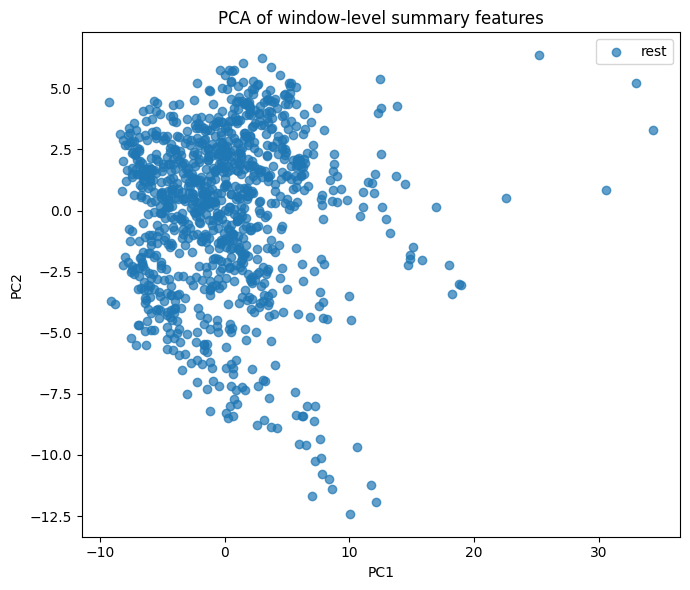

In [9]:
def extract_simple_features(dataset, max_items=1000):
    features = []
    labels = []

    n = min(len(dataset), max_items)

    for i in range(n):
        x, y = dataset[i]
        x = x.numpy()

        # Simple per-sensor statistics
        mean_abs = np.mean(np.abs(x), axis=1)
        std = np.std(x, axis=1)
        max_abs = np.max(np.abs(x), axis=1)

        feat = np.concatenate([mean_abs, std, max_abs])
        features.append(feat)
        labels.append(int(y))

    return np.array(features), np.array(labels)

def plot_pca_features(dataset, max_items=1000):
    X_feat, y = extract_simple_features(dataset, max_items=max_items)

    X_2d = PCA(n_components=2).fit_transform(X_feat)

    plt.figure(figsize=(7, 6))
    for label in sorted(set(y)):
        mask = y == label
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=INV_LABEL_MAP[label], alpha=0.7)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA of window-level summary features")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pca_features(dataset)

Dataset length: 256
Inspected windows: 256
X shape: (256, 248, 279)
y shape: (256,)
Sampling rate: 39.88235294117647
Window duration seconds: 6.995575221238938

Class counts:
rest: 64
task_story_math: 64
task_working_memory: 64
task_motor: 64


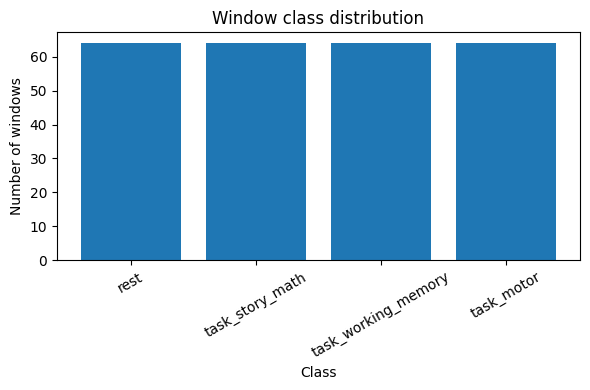

In [15]:
def describe_windows_loader(loader, class_names=None, fs=None, max_batches=None):
    xs = []
    ys = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x, y = batch[0], batch[1]

        xs.append(x.detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())

    X = np.concatenate(xs, axis=0)
    y = np.concatenate(ys, axis=0).astype(int)

    if fs is None and hasattr(loader.dataset, "sampling_rate"):
        fs = loader.dataset.sampling_rate

    if class_names is None and "INV_LABEL_MAP" in globals():
        class_names = INV_LABEL_MAP

    print("Dataset length:", len(loader.dataset))
    print("Inspected windows:", len(y))
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    if fs is not None:
        print("Sampling rate:", fs)
        print("Window duration seconds:", X.shape[-1] / fs)

    counts = Counter(y)
    print("\nClass counts:")
    for k, v in sorted(counts.items()):
        name = class_names[k] if class_names is not None and k in class_names else str(k)
        print(f"{name}: {v}")

    plt.figure(figsize=(6, 4))
    labels_plot = [
        class_names[k] if class_names is not None and k in class_names else str(k)
        for k in sorted(counts)
    ]
    values = [counts[k] for k in sorted(counts)]

    plt.bar(labels_plot, values)
    plt.title("Window class distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of windows")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return X, y


X_windows, y_windows = describe_windows_loader(dataset_loader, max_batches=32)